# 💊 Medication Box Recognition — Notebook Final Propre
## YOLOv8 + EasyOCR (AR/FR) + FastAPI
**Université Mohammed V — Master IT 2025-2026**

---
### ✅ Avant de lancer
1. **GPU T4** : Menu → Exécution → Modifier le type d'exécution → GPU T4
2. Modifie uniquement la **CELLULE 1** (chemins)
3. Lance **Ctrl+F9**

### 🔄 Anti-perte de session
- Le modèle est rechargé depuis Drive automatiquement (pas de réentraînement)
- `reference.csv` est recherché automatiquement même si le nom du dossier a un espace
- Les résultats sont sauvegardés sur Drive immédiatement après la boucle

---
## ⚙️ CELLULE 1 — Configuration (SEULE CELLULE À MODIFIER)

In [1]:
# ════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ════════════════════════════════════════════════════════════════

DOSSIER_IMAGES   = '/content/dossier_images'
DRIVE_OUTPUTS    = '/content/drive/MyDrive/MedicationProject/outputs'
MODEL_DRIVE_PATH = f'{DRIVE_OUTPUTS}/best_yolo.pt'
ZIP_SUR_DRIVE    = '/content/drive/MyDrive/images.zip'

# Liste des chemins possibles pour reference.csv (gère l'espace dans le nom)
REFERENCE_CSV_CANDIDATS = [
    '/content/drive/MyDrive/MedicationProject/reference.csv',
    '/content/drive/MyDrive/MedicationProject /reference.csv',
    '/content/reference.csv',
]

# Seuil de fuzzy matching OCR (55% = bon équilibre précision/rappel)
SEUIL_MATCHING = 55

print('✅ Configuration chargée')

✅ Configuration chargée


---
## 📦 CELLULE 2 — Installation & Imports

In [2]:
!pip install ultralytics roboflow easyocr opencv-python-headless \
             fastapi uvicorn python-multipart nest-asyncio \
             thefuzz python-Levenshtein scikit-learn \
             matplotlib seaborn tqdm pyyaml --quiet
!apt-get install -y libgl1-mesa-glx -qq

import os, re, json, time, shutil, threading, warnings, random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

warnings.filterwarnings('ignore')

import numpy as np
import cv2
import pandas as pd
import yaml
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import easyocr
from thefuzz import process, fuzz
from ultralytics import YOLO

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import nest_asyncio
from fastapi import FastAPI, UploadFile, File, HTTPException
import uvicorn
import requests as http_requests

np.random.seed(42)
random.seed(42)

gpu = os.popen('nvidia-smi --query-gpu=name --format=csv,noheader 2>/dev/null').read().strip()
print('✅ Imports OK')
print(f'   GPU : {gpu if gpu else "⚠️  NON DÉTECTÉ — active GPU T4"}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299

---
## 🔗 CELLULE 3 — Google Drive, ZIP, reference.csv

In [4]:
from google.colab import drive
drive.mount('/content/drive')
os.makedirs(DRIVE_OUTPUTS, exist_ok=True)
print(f'✅ Drive monté — outputs : {DRIVE_OUTPUTS}')

# ── Décompresser images.zip (seulement si pas déjà fait) ─────────────────────
EXTS_IMAGES = {'.jpg', '.jpeg', '.png', '.webp'}

if os.path.exists(DOSSIER_IMAGES) and \
   len([f for f in Path(DOSSIER_IMAGES).rglob('*') if f.suffix.lower() in EXTS_IMAGES]) > 0:
    imgs = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*') if p.suffix.lower() in EXTS_IMAGES]
    print(f'✅ Images déjà présentes : {len(imgs)} fichiers')
else:
    print(f'📦 Décompression de {ZIP_SUR_DRIVE}...')
    if not os.path.exists(ZIP_SUR_DRIVE):
        drive_root = '/content/drive/MyDrive/'
        zips = [f for f in os.listdir(drive_root) if f.endswith('.zip')]
        if zips:
            ZIP_SUR_DRIVE = drive_root + zips[0]
            print(f'   ZIP trouvé : {ZIP_SUR_DRIVE}')
        else:
            raise FileNotFoundError('❌ Aucun ZIP trouvé sur Drive.')
    os.makedirs(DOSSIER_IMAGES, exist_ok=True)
    os.system(f'unzip -q "{ZIP_SUR_DRIVE}" -d {DOSSIER_IMAGES}')
    imgs = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*') if p.suffix.lower() in EXTS_IMAGES]
    print(f'✅ Décompression terminée : {len(imgs)} images')

# ── Trouver reference.csv automatiquement ─────────────────────────────────────
REFERENCE_CSV = None
for chemin in REFERENCE_CSV_CANDIDATS:
    if os.path.exists(chemin):
        REFERENCE_CSV = chemin
        break

if REFERENCE_CSV is None:
    resultats = list(Path('/content/drive/MyDrive').rglob('reference.csv'))
    if resultats:
        REFERENCE_CSV = str(resultats[0])
    else:
        raise FileNotFoundError('❌ reference.csv introuvable sur Drive.')

print(f'✅ reference.csv : {REFERENCE_CSV}')
print(f'\n📊 Résumé : {len(imgs)} images | CSV trouvé | outputs → {DRIVE_OUTPUTS}')

Mounted at /content/drive
✅ Drive monté — outputs : /content/drive/MyDrive/MedicationProject/outputs
📦 Décompression de /content/drive/MyDrive/images.zip...
✅ Décompression terminée : 1548 images
✅ reference.csv : /content/drive/MyDrive/MedicationProject/reference.csv

📊 Résumé : 1548 images | CSV trouvé | outputs → /content/drive/MyDrive/MedicationProject/outputs


---
## 🤖 CELLULE 4 — Charger le modèle YOLOv8 (sans réentraîner)

In [5]:
if not os.path.exists(MODEL_DRIVE_PATH):
    raise FileNotFoundError(
        f'❌ Modèle introuvable : {MODEL_DRIVE_PATH}\n'
        f'   Réentraîne avec le notebook d\'entraînement d\'abord.'
    )

best_yolo   = YOLO(MODEL_DRIVE_PATH)
CLASS_NAMES = list(best_yolo.names.values())
NUM_CLASSES = len(CLASS_NAMES)

print(f'✅ YOLOv8 chargé : {CLASS_NAMES}')
print(f'   {NUM_CLASSES} classe(s)')

✅ YOLOv8 chargé : ['BOX']
   1 classe(s)


---
## 🔍 CELLULE 5 — EasyOCR + Base de référence

In [6]:
print('📥 Chargement EasyOCR (AR + FR)...')
USE_GPU = os.path.exists('/proc/driver/nvidia')

reader_ar = easyocr.Reader(['ar', 'en'], gpu=USE_GPU)
print('   ✅ Reader Arabe')
reader_fr = easyocr.Reader(['fr', 'en'], gpu=USE_GPU)
print('   ✅ Reader Français')

df_ref = pd.read_csv(REFERENCE_CSV, encoding='utf-8')

KNOWN_BRANDS = df_ref['nom_commercial'].str.upper().dropna().unique().tolist()

if 'forme' in df_ref.columns:
    FORMES = df_ref['forme'].str.lower().dropna().unique().tolist()
else:
    FORMES = []

NOISE_WORDS = {
    'pg','avec','indicateur','dose','doses','de','et','du','la','le',
    'les','des','par','pour','en','un','une','au','aux','ou','sur'
}

print(f'\n✅ reference.csv : {len(df_ref)} entrées, {len(KNOWN_BRANDS)} médicaments')
print(f'   Exemples : {KNOWN_BRANDS[:5]}')

📥 Chargement EasyOCR (AR + FR)...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

   ✅ Reader Arabe
Progress: |██████████████████████████████████████████████████| 100.0% Complete   ✅ Reader Français

✅ reference.csv : 7909 entrées, 7895 médicaments
   Exemples : ['DOLIPRANE 1000MG', 'DOLIPRANE 200MG', 'DOLI', 'PARASPHAN', 'CODO-LIBRANE']


---
## 🧠 CELLULE 6 — Fonctions OCR + Fusion YOLO/OCR

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# PRÉTRAITEMENT + EXTRACTION OCR
# ─────────────────────────────────────────────────────────────────────────────

def preprocess_ocr(img_path: str) -> Optional[np.ndarray]:
    """Prétraitement CLAHE — améliore l'OCR sur photos téléphone."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(blur)


def extraire_texte(img_path: str) -> List[Tuple[str, float]]:
    """Extrait le texte AR/FR/EN — fusionne et dédoublonne."""
    img = preprocess_ocr(img_path)
    if img is None:
        return []
    seen = {}
    for (_, text, conf) in reader_ar.readtext(img, detail=1, paragraph=False) + \
                            reader_fr.readtext(img, detail=1, paragraph=False):
        key = text.strip().upper()
        if key and conf > 0.20:
            if key not in seen or conf > seen[key][1]:
                seen[key] = (text.strip(), round(conf, 3))
    return list(seen.values())


# ── Construire la liste des noms arabes alignée avec KNOWN_BRANDS ────────────
if 'nom_ar' in df_ref.columns:
    KNOWN_BRANDS_AR = df_ref['nom_ar'].fillna('').astype(str).tolist()
    KNOWN_BRANDS_FR = df_ref['nom_commercial'].fillna('').astype(str).str.upper().tolist()
else:
    KNOWN_BRANDS_AR = []
    KNOWN_BRANDS_FR = KNOWN_BRANDS

print(f'✅ {sum(1 for x in KNOWN_BRANDS_AR if x.strip())} noms arabes disponibles pour matching')


# ── Construire la liste des noms arabes alignée avec KNOWN_BRANDS ────────────
if 'nom_ar' in df_ref.columns:
    KNOWN_BRANDS_AR = df_ref['nom_ar'].fillna('').astype(str).tolist()
    KNOWN_BRANDS_FR = df_ref['nom_commercial'].fillna('').astype(str).str.upper().tolist()
else:
    KNOWN_BRANDS_AR = []
    KNOWN_BRANDS_FR = KNOWN_BRANDS

print(f'✅ {sum(1 for x in KNOWN_BRANDS_AR if x.strip())} noms arabes disponibles pour matching')


def matcher_medicament(textes: List[Tuple[str, float]]) -> Tuple[str, float]:
    """
    Fuzzy matching contre KNOWN_BRANDS (français) ET KNOWN_BRANDS_AR (arabe).
    Le texte OCR peut contenir l'un ou l'autre — on teste les deux.
    """
    if not textes:
        return '?', 0.0

    full_text = ' '.join(t for t, _ in textes)
    full_upper = full_text.upper()

    best_med, best_score = '?', 0

    # ── 1. Matching FRANÇAIS (latin) ───────────────────────────────────────────
    if KNOWN_BRANDS_FR:
        match_fr, score_fr = process.extractOne(full_upper, KNOWN_BRANDS_FR, scorer=fuzz.partial_ratio)
        if score_fr > best_score:
            best_med, best_score = match_fr, score_fr

    # ── 2. Matching ARABE ────────────────────────────────────────────────────
    if KNOWN_BRANDS_AR:
        candidats_ar = [b for b in KNOWN_BRANDS_AR if b.strip()]
        if candidats_ar:
            match_ar, score_ar = process.extractOne(full_text, candidats_ar, scorer=fuzz.partial_ratio)
            if score_ar > best_score:
                # Retrouver le nom commercial français correspondant
                idx = KNOWN_BRANDS_AR.index(match_ar)
                best_med   = KNOWN_BRANDS_FR[idx]
                best_score = score_ar

    if best_score >= SEUIL_MATCHING:
        return best_med, round(best_score / 100, 3)

    # ── 3. Fallback mot à mot (français + arabe) ──────────────────────────────
    for texte, _ in textes:
        t = texte.strip()
        if len(t) < 3 or t.lower() in NOISE_WORDS:
            continue

        m_fr, s_fr = process.extractOne(t.upper(), KNOWN_BRANDS_FR, scorer=fuzz.ratio)
        if s_fr > best_score:
            best_med, best_score = m_fr, s_fr

        if KNOWN_BRANDS_AR:
            candidats_ar = [b for b in KNOWN_BRANDS_AR if b.strip()]
            if candidats_ar:
                m_ar, s_ar = process.extractOne(t, candidats_ar, scorer=fuzz.ratio)
                if s_ar > best_score:
                    idx = KNOWN_BRANDS_AR.index(m_ar)
                    best_med   = KNOWN_BRANDS_FR[idx]
                    best_score = s_ar

    if best_score >= SEUIL_MATCHING:
        return best_med, round(best_score / 100, 3)

    return '?', 0.0


print('✅ matcher_medicament mis à jour — matching FR + AR')


def detecter_forme(textes: List[Tuple[str, float]]) -> str:
    """Identifie la forme galénique."""
    full = ' '.join(t for t, _ in textes).lower()
    for forme in FORMES:
        if forme in full:
            return forme.capitalize()
    return '?'


def pipeline_ocr(img_path: str) -> Dict:
    """Pipeline OCR complet."""
    try:
        textes = extraire_texte(img_path)
        med, conf_ocr = matcher_medicament(textes)
        return {
            'medicament'    : med,
            'confiance_ocr' : conf_ocr,
            'dosage'        : detecter_dosage(textes),
            'forme'         : detecter_forme(textes),
            'texte_brut'    : ' '.join(t for t, _ in textes),
        }
    except Exception as e:
        return {'medicament': '?', 'confiance_ocr': 0.0, 'dosage': '?',
                'forme': '?', 'texte_brut': '', 'erreur': str(e)}


# ─────────────────────────────────────────────────────────────────────────────
# FUSION YOLO + OCR  (logique validée — ne pas modifier)
# ─────────────────────────────────────────────────────────────────────────────

def reconnaitre_medicament(img_path: str, conf_yolo: float = 0.3) -> Dict:
    """
    Pipeline complet :
      1. YOLOv8  → classe visuelle
      2. EasyOCR → texte AR/FR/EN + fuzzy matching
      3. Fusion  → décision finale
    """
    t0 = time.time()

    yolo_class, yolo_conf = '?', 0.0
    try:
        pred = best_yolo.predict(img_path, conf=conf_yolo, verbose=False)
        if pred and len(pred[0].boxes) > 0:
            boxes      = pred[0].boxes
            idx        = int(boxes.conf.argmax())
            cls_id     = int(boxes.cls[idx])
            yolo_class = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else '?'
            yolo_conf  = float(boxes.conf[idx])
    except Exception:
        pass

    ocr      = pipeline_ocr(img_path)
    ocr_med  = ocr['medicament']
    ocr_conf = ocr['confiance_ocr']

    yu = yolo_class.upper().replace('-', ' ').replace('_', ' ')
    ou = ocr_med.upper()

    if yolo_class != '?' and ocr_med != '?' and (
        yu in ou or ou in yu or fuzz.partial_ratio(yu, ou) >= 75
    ):
        final_med  = ocr_med
        final_conf = min(1.0, (yolo_conf + ocr_conf) / 2 + 0.1)
        methode    = 'accord_yolo_ocr'
    elif yolo_conf >= 0.65 and (ocr_conf < 0.5 or ocr_med == '?'):
        final_med, final_conf, methode = yolo_class, yolo_conf, 'yolo_seul'
    elif ocr_conf >= 0.60:
        final_med, final_conf, methode = ocr_med, ocr_conf, 'ocr_seul'
    elif yolo_class != '?':
        final_med, final_conf, methode = yolo_class, yolo_conf, 'yolo_fallback'
    else:
        final_med  = ocr_med if ocr_med != '?' else '?'
        final_conf = ocr_conf
        methode    = 'ocr_fallback'

    db_info = {}
    if final_med != '?':
        mask = df_ref['nom_commercial'].str.upper() == final_med.upper()
        if mask.any():
            db_info = df_ref[mask].iloc[0].dropna().to_dict()

    return {
        'medicament'    : final_med,
        'confiance'     : round(final_conf, 3),
        'methode'       : methode,
        'yolo_classe'   : yolo_class,
        'yolo_confiance': round(yolo_conf, 3),
        'ocr_medicament': ocr_med,
        'ocr_confiance' : ocr_conf,
        'dosage'        : ocr['dosage'],
        'forme'         : ocr['forme'],
        'texte_ocr'     : ocr['texte_brut'],
        'db_info'       : db_info,
        'latence_s'     : round(time.time() - t0, 2),
    }


print(f'✅ Fonctions OCR + Fusion définies (seuil matching = {SEUIL_MATCHING}%)')

imgs_all = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*')
            if p.is_file() and p.suffix.lower() in EXTS_IMAGES]

if imgs_all:
    r = reconnaitre_medicament(imgs_all[0])
    print(f'\n🔬 Test rapide → {os.path.basename(imgs_all[0])}')
    print(f'   Médicament : {r["medicament"]}  ({r["confiance"]:.0%})')
    print(f'   Méthode    : {r["methode"]}')
    print(f'   Dosage     : {r["dosage"]}')
    print(f'   Latence    : {r["latence_s"]}s')
else:
    print(f'⚠️ Aucune image dans {DOSSIER_IMAGES}')

✅ 43 noms arabes disponibles pour matching
✅ 43 noms arabes disponibles pour matching
✅ matcher_medicament mis à jour — matching FR + AR
✅ Fonctions OCR + Fusion définies (seuil matching = 55%)

🔬 Test rapide → bruit_IMG-20260612-WA0345.jpg
   Médicament : ?  (0%)
   Méthode    : ocr_fallback
   Dosage     : ?
   Latence    : 5.19s


---
## 🔄 CELLULE 7 — Boucle d'évaluation → génère df_eval

In [8]:
imgs_all = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*')
            if p.is_file() and p.suffix.lower() in EXTS_IMAGES]

if not imgs_all:
    raise RuntimeError(f'❌ Aucune image dans {DOSSIER_IMAGES}.')

NOM_RACINE   = Path(DOSSIER_IMAGES).name
ground_truth = {}

for chemin in imgs_all:
    parent = Path(chemin).parent.name
    ground_truth[chemin] = parent.upper() if parent != NOM_RACINE else 'INCONNU'

has_gt = any(v != 'INCONNU' for v in ground_truth.values())

print(f'📋 Images        : {len(imgs_all)}')
print(f'   Avec label    : {sum(1 for v in ground_truth.values() if v != "INCONNU")}')
print(f'   Sans label    : {sum(1 for v in ground_truth.values() if v == "INCONNU")}')
print(f'   Accuracy dispo: {"OUI" if has_gt else "NON (images en vrac)"}')

print(f'\n🔄 Évaluation sur {len(imgs_all)} images...')

eval_results = []

for img_path in tqdm(imgs_all, desc='Reconnaissance', unit='img'):
    true_label = ground_truth.get(img_path, 'INCONNU')
    pred       = reconnaitre_medicament(img_path)

    correct = (
        true_label != 'INCONNU' and
        fuzz.partial_ratio(pred['medicament'].upper(), true_label.upper()) >= 85
    )

    eval_results.append({
        'image'         : os.path.basename(img_path),
        'vrai_label'    : true_label,
        'prediction'    : pred['medicament'],
        'confiance'     : pred['confiance'],
        'methode'       : pred['methode'],
        'yolo_classe'   : pred['yolo_classe'],
        'yolo_confiance': pred['yolo_confiance'],
        'ocr_medicament': pred['ocr_medicament'],
        'ocr_confiance' : pred['ocr_confiance'],
        'dosage'        : pred['dosage'],
        'latence_s'     : pred['latence_s'],
        'correct'       : correct,
    })

df_eval = pd.DataFrame(eval_results)

csv_local = '/content/evaluation_resultats.csv'
csv_drive = f'{DRIVE_OUTPUTS}/evaluation_resultats.csv'
df_eval.to_csv(csv_local, index=False)
df_eval.to_csv(csv_drive, index=False)

print(f'\n✅ df_eval : {len(df_eval)} lignes')
print(f'   Sauvegardé Drive : {csv_drive}')
print()
print(df_eval[['image','vrai_label','prediction','confiance','methode']].head().to_string(index=False))

📋 Images        : 1548
   Avec label    : 1548
   Sans label    : 0
   Accuracy dispo: OUI

🔄 Évaluation sur 1548 images...


Reconnaissance: 100%|██████████| 1548/1548 [1:05:34<00:00,  2.54s/img]



✅ df_eval : 1548 lignes
   Sauvegardé Drive : /content/drive/MyDrive/MedicationProject/outputs/evaluation_resultats.csv

                         image                    vrai_label prediction  confiance      methode
 bruit_IMG-20260612-WA0345.jpg PHOTOS MEDICAMENTS AUGMENTEES          ?      0.000 ocr_fallback
         lum_1781268751588.jpg PHOTOS MEDICAMENTS AUGMENTEES          ?      0.000 ocr_fallback
         rot_1781527997725.jpg PHOTOS MEDICAMENTS AUGMENTEES          ?      0.000 ocr_fallback
lum_IMG-20260612-WA0013(1).jpg PHOTOS MEDICAMENTS AUGMENTEES        BOX      0.693    yolo_seul
   lum_IMG-20260612-WA0126.jpg PHOTOS MEDICAMENTS AUGMENTEES        BOX      0.836    yolo_seul


---
## 📊 CELLULE 8 — Métriques

In [9]:
assert 'df_eval' in dir() and len(df_eval) > 0, "❌ Lance d'abord la CELLULE 7"

has_gt = any(v != 'INCONNU' for v in df_eval['vrai_label'])

print('='*55)
print('📊 MÉTRIQUES')
print('='*55)

total      = len(df_eval)
identifies = df_eval[df_eval['prediction'] != '?']
non_id     = df_eval[df_eval['prediction'] == '?']

if has_gt:
    df_gt  = df_eval[df_eval['vrai_label'] != 'INCONNU']
    y_true = df_gt['vrai_label'].tolist()
    y_pred = df_gt['prediction'].tolist()

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f'  Images évaluées : {len(df_gt)}')
    print(f'  Accuracy        : {acc*100:.2f}%')
    print(f'  Precision       : {prec*100:.2f}%')
    print(f'  Recall          : {rec*100:.2f}%')
    print(f'  F1-Score        : {f1*100:.2f}%')

    report = classification_report(y_true, y_pred, zero_division=0)
    print(f'\n  Rapport détaillé :\n{report}')

    rapport_txt = (
        f'Accuracy  : {acc*100:.2f}%\nPrecision : {prec*100:.2f}%\n'
        f'Recall    : {rec*100:.2f}%\nF1-Score  : {f1*100:.2f}%\n\n{report}'
    )
else:
    acc = prec = rec = f1 = None
    print(f'  Taux d\'identification : {len(identifies)/total*100:.1f}% ({len(identifies)}/{total})')
    print(f'  Non identifiés         : {len(non_id)/total*100:.1f}% ({len(non_id)})')
    print('\n  ⚠️  Accuracy non calculable — images sans labels (ground truth absent)')

    rapport_txt = (
        f"Taux d'identification : {len(identifies)/total*100:.1f}% ({len(identifies)}/{total})\n"
        f"Non identifiés        : {len(non_id)/total*100:.1f}%\n"
    )

print(f'\n  Confiance moyenne : {df_eval["confiance"].mean():.3f}')
print(f'  Latence moyenne   : {df_eval["latence_s"].mean():.2f}s/image')
print(f'\n  Méthodes de décision :')
for m, c in df_eval['methode'].value_counts().items():
    print(f'    {m:<25}: {c} ({c/total*100:.1f}%)')

with open(f'{DRIVE_OUTPUTS}/rapport_evaluation.txt', 'w', encoding='utf-8') as f:
    f.write(rapport_txt)
print(f'\n✅ Rapport sauvegardé sur Drive')

📊 MÉTRIQUES
  Images évaluées : 1548
  Accuracy        : 0.00%
  Precision       : 0.00%
  Recall          : 0.00%
  F1-Score        : 0.00%

  Rapport détaillé :
                               precision    recall  f1-score   support

                            ?       0.00      0.00      0.00       0.0
                          BOX       0.00      0.00      0.00       0.0
PHOTOS MEDICAMENTS AUGMENTEES       0.00      0.00      0.00    1548.0

                     accuracy                           0.00    1548.0
                    macro avg       0.00      0.00      0.00    1548.0
                 weighted avg       0.00      0.00      0.00    1548.0


  Confiance moyenne : 0.129
  Latence moyenne   : 2.54s/image

  Méthodes de décision :
    ocr_fallback             : 1217 (78.6%)
    yolo_fallback            : 176 (11.4%)
    yolo_seul                : 155 (10.0%)

✅ Rapport sauvegardé sur Drive


---
## 🎨 CELLULE 9 — Visualisations

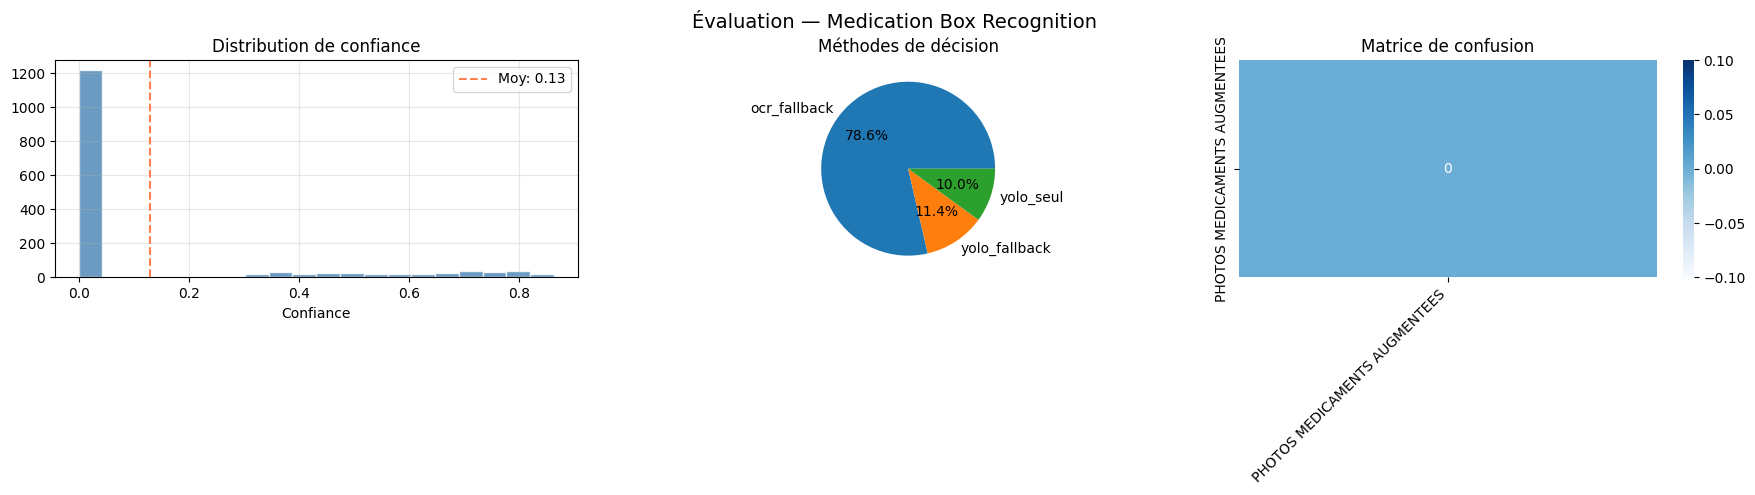

✅ Visualisations sauvegardées sur Drive


In [10]:
assert 'df_eval' in dir() and len(df_eval) > 0, "❌ Lance d'abord la CELLULE 7"

has_gt = any(v != 'INCONNU' for v in df_eval['vrai_label'])
if has_gt:
    df_gt  = df_eval[df_eval['vrai_label'] != 'INCONNU']
    y_true = df_gt['vrai_label'].tolist()
    y_pred = df_gt['prediction'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Évaluation — Medication Box Recognition', fontsize=14)

axes[0].hist(df_eval['confiance'].dropna(), bins=20,
             color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(df_eval['confiance'].mean(), color='coral', linestyle='--',
                label=f'Moy: {df_eval["confiance"].mean():.2f}')
axes[0].set_title('Distribution de confiance')
axes[0].set_xlabel('Confiance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

meth = df_eval['methode'].value_counts()
axes[1].pie(meth.values, labels=meth.index, autopct='%1.1f%%',
            colors=['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd'][:len(meth)])
axes[1].set_title('Méthodes de décision')

if has_gt and len(set(y_true)) <= 20:
    labels_cm = sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels_cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_cm, yticklabels=labels_cm, ax=axes[2])
    axes[2].set_title('Matrice de confusion')
    plt.setp(axes[2].get_xticklabels(), rotation=45, ha='right')
else:
    top = (df_eval[df_eval['prediction'] != '?']['prediction']
           .value_counts().head(15).iloc[::-1])
    axes[2].barh(range(len(top)), top.values, color='teal', alpha=0.8)
    axes[2].set_yticks(range(len(top)))
    axes[2].set_yticklabels(top.index)
    axes[2].set_title('Top 15 médicaments détectés')
    axes[2].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
fig.subplots_adjust(top=0.88)

viz_path = f'{DRIVE_OUTPUTS}/evaluation_visualisations.png'
plt.savefig(viz_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'✅ Visualisations sauvegardées sur Drive')

---
## 🌐 CELLULE 10 — API FastAPI

In [11]:
nest_asyncio.apply()

app = FastAPI(
    title       = 'Medication Box Recognition API',
    description = 'YOLOv8 + EasyOCR (AR/FR/EN) + Fuzzy Matching — Master IT 2025-2026',
    version     = '3.0',
    docs_url    = '/docs',
)

@app.get('/')
async def root():
    return {
        'status'         : 'running',
        'version'        : '3.0',
        'classes_yolo'   : NUM_CLASSES,
        'medicaments_db' : len(KNOWN_BRANDS),
    }

@app.post('/recognize')
async def recognize(file: UploadFile = File(...), conf_yolo: float = 0.3):
    """
    Reconnaît un médicament depuis une photo de sa boîte.
    - **file** : image JPG, PNG ou WEBP (max 15 MB)
    - **conf_yolo** : seuil YOLO (défaut 0.3)
    """
    if not file.filename.lower().endswith(('.jpg','.jpeg','.png','.webp')):
        raise HTTPException(400, 'Format non supporté.')
    temp = f'/tmp/api_{int(time.time())}_{file.filename}'
    try:
        content = await file.read()
        if len(content) > 15 * 1024 * 1024:
            raise HTTPException(413, 'Image > 15 MB.')
        with open(temp, 'wb') as f_:
            f_.write(content)
        r = reconnaitre_medicament(temp, conf_yolo)
        return {
            'status'     : 'success',
            'image'      : file.filename,
            'prediction' : {'medicament': r['medicament'],
                            'confiance' : r['confiance'],
                            'methode'   : r['methode']},
            'yolo'       : {'classe'   : r['yolo_classe'],
                            'confiance': r['yolo_confiance']},
            'ocr'        : {'medicament': r['ocr_medicament'],
                            'dosage'    : r['dosage'],
                            'forme'     : r['forme'],
                            'texte_brut': r['texte_ocr']},
            'db_info'    : r['db_info'],
            'latence_s'  : r['latence_s'],
        }
    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(500, str(e))
    finally:
        if os.path.exists(temp):
            os.remove(temp)

@app.get('/medicaments')
async def liste():
    return {'total': len(KNOWN_BRANDS), 'medicaments': sorted(KNOWN_BRANDS)}

@app.get('/medicaments/{nom}')
async def info(nom: str):
    mask = df_ref['nom_commercial'].str.upper() == nom.upper()
    if not mask.any():
        raise HTTPException(404, f"'{nom}' non trouvé.")
    return df_ref[mask].to_dict(orient='records')

@app.get('/stats')
async def stats():
    return {
        'modele'         : 'YOLOv8n fine-tuné Roboflow',
        'ocr'            : 'EasyOCR AR/FR/EN',
        'classes'        : CLASS_NAMES,
        'medicaments_db' : len(KNOWN_BRANDS),
        'images_testees' : len(df_eval) if 'df_eval' in globals() else 0,
        'accuracy'       : round(acc, 4) if globals().get('acc') is not None else 'N/A',
        'f1'             : round(f1,  4) if globals().get('f1')  is not None else 'N/A',
    }

threading.Thread(
    target=lambda: uvicorn.run(app, host='0.0.0.0', port=8000, log_level='warning'),
    daemon=True
).start()
time.sleep(3)

try:
    d = http_requests.get('http://localhost:8000/').json()
    print('✅ API opérationnelle !')
    print(f'   Classes     : {d["classes_yolo"]}')
    print(f'   Médicaments : {d["medicaments_db"]} dans la base')
    print('\n📖 Swagger : http://localhost:8000/docs')
except Exception as e:
    print(f'❌ Erreur : {e}')

✅ API opérationnelle !
   Classes     : 1
   Médicaments : 7895 dans la base

📖 Swagger : http://localhost:8000/docs


In [ ]:
# ── Vérification avant test ────────────────────────────────────────────────────
if 'reconnaitre_medicament' not in dir():
    print('❌ Le pipeline n\'est pas chargé en mémoire.')
    print('   → Relance les Cellules 1 à 6 dans l\'ordre avant de continuer.')
else:
    from google.colab import files
    from IPython.display import display, HTML
    import base64, os

    print('📤 Choisis une image sur ton ordinateur...')
    uploaded = files.upload()

    for nom_fichier in uploaded.keys():
        chemin_local = f'/content/{nom_fichier}'
        r = reconnaitre_medicament(chemin_local)

        with open(chemin_local, 'rb') as f:
            img_b64 = base64.b64encode(f.read()).decode()
        ext = nom_fichier.split('.')[-1].lower()

        conf_pct = int(r['confiance'] * 100)
        conf_color = '#10b981' if conf_pct >= 70 else '#f59e0b' if conf_pct >= 40 else '#ef4444'

        html_card = f"""
        <div style="display:flex; gap:20px; max-width:680px; margin:1.5rem 0;
                    font-family:-apple-system,sans-serif; border:1px solid #e5e5e5;
                    border-radius:14px; overflow:hidden; background:white;">
          <div style="flex:0 0 220px; background:#f5f5f4; display:flex;
                      align-items:center; justify-content:center; padding:12px;">
            <img src="data:image/{ext};base64,{img_b64}"
                 style="max-width:100%; max-height:280px; border-radius:8px;
                        box-shadow:0 1px 3px rgba(0,0,0,0.15);">
          </div>
          <div style="flex:1; padding:18px 20px 18px 4px;">
            <div style="display:flex; align-items:center; justify-content:space-between; margin-bottom:14px;">
              <span style="font-size:11px; color:#999; font-family:monospace;">{nom_fichier}</span>
              <span style="font-size:11px; padding:3px 10px; border-radius:10px;
                           background:{'#d1fae5' if r['medicament']!='?' else '#fee'};
                           color:{'#065f46' if r['medicament']!='?' else '#c00'};">
                {'✓ Identifié' if r['medicament']!='?' else '✗ Non identifié'}
              </span>
            </div>
            <div style="font-size:20px; font-weight:700; color:#1a1a1a; margin-bottom:2px;">
              {r['medicament']}
            </div>
            <div style="font-size:12px; color:#999; margin-bottom:16px;">
              via {r['methode']}
            </div>
            <div style="display:flex; align-items:center; gap:8px; margin-bottom:14px;">
              <div style="flex:1; height:8px; background:#e5e5e5; border-radius:4px; overflow:hidden;">
                <div style="height:100%; width:{conf_pct}%; background:{conf_color};"></div>
              </div>
              <span style="font-size:13px; font-weight:600; color:{conf_color}; min-width:36px;">
                {conf_pct}%
              </span>
            </div>
            <table style="width:100%; font-size:13px; border-collapse:collapse;">
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Dosage</td>
                  <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['dosage']}</td></tr>
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Forme</td>
                  <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['forme']}</td></tr>
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Latence</td>
                  <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['latence_s']}s</td></tr>
            </table>
            <div style="margin-top:14px; padding:10px 12px; background:#f5f5f4;
                        border-radius:8px; font-size:11px; color:#666; line-height:1.5;
                        max-height:60px; overflow-y:auto;">
              <strong style="color:#999;">Texte OCR brut :</strong><br>
              {r['texte_ocr'] if r['texte_ocr'] else '(aucun texte détecté)'}
            </div>
          </div>
        </div>
        """
        display(HTML(html_card))

---
## 🧪 CELLULE 11 — Test live API (5 images)

In [ ]:
# ── Vérification avant test ────────────────────────────────────────────────────
if 'reconnaitre_medicament' not in dir():
    print('❌ Le pipeline n\'est pas chargé en mémoire.')
    print('   → Relance les Cellules 1 à 6 dans l\'ordre avant de continuer.')
else:
    from google.colab import files
    from IPython.display import display, HTML
    import base64, os

    print('📤 Choisis une image sur ton ordinateur...')
    uploaded = files.upload()

    for nom_fichier in uploaded.keys():
        chemin_local = f'/content/{nom_fichier}'
        r = reconnaitre_medicament(chemin_local)

        with open(chemin_local, 'rb') as f:
            img_b64 = base64.b64encode(f.read()).decode()
        ext = nom_fichier.split('.')[-1].lower()

        conf_pct = int(r['confiance'] * 100)
        conf_color = '#10b981' if conf_pct >= 70 else '#f59e0b' if conf_pct >= 40 else '#ef4444'

        # ── Récupérer infos supplémentaires depuis reference.csv ──────────────
        db = r.get('db_info', {})
        nom_ar      = db.get('nom_ar', '?')
        prix        = db.get('prix', '?')
        laboratoire = db.get('laboratoire', '?')

        html_card = f"""
        <div style="display:flex; gap:20px; max-width:680px; margin:1.5rem 0;
                    font-family:-apple-system,sans-serif; border:1px solid #e5e5e5;
                    border-radius:14px; overflow:hidden; background:white;">
          <div style="flex:0 0 220px; background:#f5f5f4; display:flex;
                      align-items:center; justify-content:center; padding:12px;">
            <img src="data:image/{ext};base64,{img_b64}"
                 style="max-width:100%; max-height:280px; border-radius:8px;
                        box-shadow:0 1px 3px rgba(0,0,0,0.15);">
          </div>
          <div style="flex:1; padding:18px 20px 18px 4px;">
            <div style="display:flex; align-items:center; justify-content:space-between; margin-bottom:14px;">
              <span style="font-size:11px; color:#999; font-family:monospace;">{nom_fichier}</span>
              <span style="font-size:11px; padding:3px 10px; border-radius:10px;
                           background:{'#d1fae5' if r['medicament']!='?' else '#fee'};
                           color:{'#065f46' if r['medicament']!='?' else '#c00'};">
                {'✓ Identifié' if r['medicament']!='?' else '✗ Non identifié'}
              </span>
            </div>

            <div style="font-size:20px; font-weight:700; color:#1a1a1a; margin-bottom:2px;">
              {r['medicament']}
            </div>
            <div dir="rtl" style="font-size:16px; font-weight:600; color:#444;
                                  margin-bottom:2px; font-family:'Segoe UI',Tahoma,sans-serif;">
              {nom_ar}
            </div>
            <div style="font-size:12px; color:#999; margin-bottom:16px;">
              via {r['methode']}
            </div>

            <div style="display:flex; align-items:center; gap:8px; margin-bottom:14px;">
              <div style="flex:1; height:8px; background:#e5e5e5; border-radius:4px; overflow:hidden;">
                <div style="height:100%; width:{conf_pct}%; background:{conf_color};"></div>
              </div>
              <span style="font-size:13px; font-weight:600; color:{conf_color}; min-width:36px;">
                {conf_pct}%
              </span>
            </div>

            <table style="width:100%; font-size:13px; border-collapse:collapse;">
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Prix</td>
                  <td style="padding:6px 0; text-align:right; font-weight:700; color:#0c447c; border-top:1px solid #f0f0f0;">{prix}</td></tr>
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Laboratoire</td>
                  <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{laboratoire}</td></tr>
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Dosage</td>
                  <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['dosage']}</td></tr>
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Forme</td>
                  <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['forme']}</td></tr>
              <tr><td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Latence</td>
                  <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['latence_s']}s</td></tr>
            </table>

            <div style="margin-top:14px; padding:10px 12px; background:#f5f5f4;
                        border-radius:8px; font-size:11px; color:#666; line-height:1.5;
                        max-height:60px; overflow-y:auto;">
              <strong style="color:#999;">Texte OCR brut :</strong><br>
              {r['texte_ocr'] if r['texte_ocr'] else '(aucun texte détecté)'}
            </div>
          </div>
        </div>
        """
        display(HTML(html_card))

In [ ]:
# Diagnostic — pourquoi l'OCR ne détecte rien ?
chemin_test = '/content/WhatsApp Image 2026-06-12 at 15.06.19.jpeg'  # adapte le nom exact

import os
print(f"Fichier existe : {os.path.exists(chemin_test)}")

if os.path.exists(chemin_test):
    # Test direct de chaque étape
    img_preprocessed = preprocess_ocr(chemin_test)
    print(f"Prétraitement OK : {img_preprocessed is not None}")
    if img_preprocessed is not None:
        print(f"Shape image : {img_preprocessed.shape}")

    # Tester EasyOCR directement sans le wrapper
    print("\nTest reader_ar direct :")
    res_ar = reader_ar.readtext(img_preprocessed, detail=1)
    print(f"  Résultats AR : {len(res_ar)}")
    for r in res_ar[:5]:
        print(f"    {r}")

    print("\nTest reader_fr direct :")
    res_fr = reader_fr.readtext(img_preprocessed, detail=1)
    print(f"  Résultats FR : {len(res_fr)}")
    for r in res_fr[:5]:
        print(f"    {r}")

In [ ]:
# Diagnostic — pourquoi extraire_texte() retourne vide alors que readtext() marche
textes = extraire_texte(chemin_test)
print(f"extraire_texte() résultat : {len(textes)} éléments")
for t in textes:
    print(f"   {t}")

print(f"\nreconnaitre_medicament() résultat complet :")
r = reconnaitre_medicament(chemin_test)
for k, v in r.items():
    print(f"   {k}: {v}")

In [ ]:
# Isoler exactement où pipeline_ocr() échoue
import traceback

try:
    textes = extraire_texte(chemin_test)
    print(f"✅ extraire_texte OK : {len(textes)} éléments")

    med, conf_ocr = matcher_medicament(textes)
    print(f"✅ matcher_medicament OK : {med} ({conf_ocr})")

    dosage = detecter_dosage(textes)
    print(f"✅ detecter_dosage OK : {dosage}")

    forme = detecter_forme(textes)
    print(f"✅ detecter_forme OK : {forme}")

except Exception as e:
    print(f"❌ ERREUR : {e}")
    traceback.print_exc()

In [ ]:
print('detecter_dosage' in dir())
print('detecter_forme' in dir())
print('preprocess_ocr' in dir())
print('extraire_texte' in dir())
print('matcher_medicament' in dir())

In [ ]:
def detecter_dosage(textes):
    """Extrait le dosage par regex (patterns élargis)."""
    full = ' '.join(t for t, _ in textes).lower()
    patterns = [
        r'\d{1,4}\s*/\s*\d{1,4}\s*/\s*\d{1,4}\s*(?:mg|ml|mcg|g|%)?',
        r'\d{1,4}\s*/\s*\d{1,4}\s*(?:mg|ml|mcg|g|%)?',
        r'\d+[.,]?\d*\s*(?:mg|mcg|µg|g|ml|%|ui|iu)',
        r'\d+\s*(?:mg|mcg|g|ml|%)',
    ]
    for pat in patterns:
        m = re.search(pat, full)
        if m:
            return m.group().strip()
    return '?'


def detecter_forme(textes):
    """Identifie la forme galénique."""
    full = ' '.join(t for t, _ in textes).lower()
    for forme in FORMES:
        if forme in full:
            return forme.capitalize()
    return '?'


def pipeline_ocr(img_path):
    """Pipeline OCR complet."""
    try:
        textes = extraire_texte(img_path)
        med, conf_ocr = matcher_medicament(textes)
        return {
            'medicament'    : med,
            'confiance_ocr' : conf_ocr,
            'dosage'        : detecter_dosage(textes),
            'forme'         : detecter_forme(textes),
            'texte_brut'    : ' '.join(t for t, _ in textes),
        }
    except Exception as e:
        print(f'⚠️ Erreur pipeline_ocr: {e}')  # affiche l'erreur au lieu de la cacher
        return {'medicament': '?', 'confiance_ocr': 0.0, 'dosage': '?',
                'forme': '?', 'texte_brut': '', 'erreur': str(e)}


def matcher_medicament(textes):
    """
    Stratégie : priorise le texte ayant la PLUS HAUTE confiance OCR individuelle
    et la position la plus probable d'être le nom de marque (généralement
    le texte le plus confiant ET le plus long parmi les premiers détectés).

    Évite que des mots génériques (Vitamine C, Paracétamol, Dosage...)
    écrasent le vrai nom de marque (DoliGrippe, Doliprane...).
    """
    if not textes:
        return '?', 0.0

    # Mots génériques pharmaceutiques à ignorer pour le matching de marque
    MOTS_GENERIQUES = {
        'VITAMINE C', 'VITAMINE D', 'VITAMINE B', 'PARACETAMOL', 'PARACÉTAMOL',
        'IBUPROFENE', 'IBUPROFÈNE', 'ASPIRINE', 'AMOXICILLINE', 'ZINC',
        'CALCIUM', 'MAGNESIUM', 'MAGNÉSIUM', 'CODEINE', 'CODÉINE',
    }

    full_text  = ' '.join(t for t, _ in textes)
    full_upper = full_text.upper()

    candidats = []

    if KNOWN_BRANDS_FR:
        matches_fr = process.extract(full_upper, KNOWN_BRANDS_FR, scorer=fuzz.partial_ratio, limit=8)
        candidats.extend(matches_fr)

    if KNOWN_BRANDS_AR:
        candidats_ar = [b for b in KNOWN_BRANDS_AR if b.strip()]
        if candidats_ar:
            matches_ar = process.extract(full_text, candidats_ar, scorer=fuzz.partial_ratio, limit=8)
            for nom_ar, score in matches_ar:
                idx = KNOWN_BRANDS_AR.index(nom_ar)
                candidats.append((KNOWN_BRANDS_FR[idx], score))

    if not candidats:
        return '?', 0.0

    candidats_valides = [
        (nom, score) for nom, score in candidats
        if score >= SEUIL_MATCHING and nom.upper().strip() not in MOTS_GENERIQUES
    ]

    if not candidats_valides:
        return '?', 0.0

    score_max = max(s for _, s in candidats_valides)
    meilleurs = [n for n, s in candidats_valides if s == score_max]
    meilleur_nom = max(meilleurs, key=len)

    return meilleur_nom, round(score_max / 100, 3)


print('✅ matcher_medicament v4 — exclut les mots génériques pharmaceutiques')



In [ ]:
r = reconnaitre_medicament(chemin_test)
print(f"Médicament : {r['medicament']}")
print(f"Confiance  : {r['confiance']:.0%}")
print(f"Dosage     : {r['dosage']}")
print(f"Texte OCR  : {r['texte_ocr'][:80]}")

In [ ]:
# Diagnostic : pourquoi LOREUS et pas DOLIPRANE ?
texte_test = "مغ 12 مسحوق محلول طريق من 27 كلغ 9 دوليبران ان باراسيتامول 500 كيس جرعة لتحضير الترطب الأوجاع و الحمى"

# Voir le score de DOLIPRANE
from thefuzz import fuzz, process
score_doliprane = fuzz.partial_ratio(texte_test.upper(), "DOLIPRANE")
print(f"Score DOLIPRANE : {score_doliprane}")

# Voir quel est le meilleur match trouvé
match, score = process.extractOne(texte_test.upper(), KNOWN_BRANDS, scorer=fuzz.partial_ratio)
print(f"Meilleur match  : {match} ({score}%)")

# Vérifier si DOLIPRANE existe bien dans la base
doliprane_variants = [b for b in KNOWN_BRANDS if 'DOLI' in b.upper()]
print(f"\nVariantes Doliprane dans la base : {doliprane_variants}")

In [ ]:
# ── Test avec image choisie + design carte image/résultats côte à côte ────────
from google.colab import files
from IPython.display import display, HTML
import base64, os

print('📤 Choisis une image sur ton ordinateur...')
uploaded = files.upload()

for nom_fichier in uploaded.keys():
    chemin_local = f'/content/{nom_fichier}'

    # Lancer la reconnaissance
    r = reconnaitre_medicament(chemin_local)

    # Encoder l'image en base64 pour l'afficher dans le HTML
    with open(chemin_local, 'rb') as f:
        img_b64 = base64.b64encode(f.read()).decode()
    ext = nom_fichier.split('.')[-1].lower()

    conf_pct = int(r['confiance'] * 100)
    conf_color = '#10b981' if conf_pct >= 70 else '#f59e0b' if conf_pct >= 40 else '#ef4444'

    html_card = f"""
    <div style="display:flex; gap:20px; max-width:680px; margin:1.5rem 0;
                font-family:-apple-system,sans-serif; border:1px solid #e5e5e5;
                border-radius:14px; overflow:hidden; background:white;">

      <div style="flex:0 0 220px; background:#f5f5f4; display:flex;
                  align-items:center; justify-content:center; padding:12px;">
        <img src="data:image/{ext};base64,{img_b64}"
             style="max-width:100%; max-height:280px; border-radius:8px;
                    box-shadow:0 1px 3px rgba(0,0,0,0.15);">
      </div>

      <div style="flex:1; padding:18px 20px 18px 4px;">
        <div style="display:flex; align-items:center; justify-content:space-between; margin-bottom:14px;">
          <span style="font-size:11px; color:#999; font-family:monospace;">{nom_fichier}</span>
          <span style="font-size:11px; padding:3px 10px; border-radius:10px;
                       background:{'#d1fae5' if r['medicament']!='?' else '#fee'};
                       color:{'#065f46' if r['medicament']!='?' else '#c00'};">
            {'✓ Identifié' if r['medicament']!='?' else '✗ Non identifié'}
          </span>
        </div>

        <div style="font-size:20px; font-weight:700; color:#1a1a1a; margin-bottom:2px;">
          {r['medicament']}
        </div>
        <div style="font-size:12px; color:#999; margin-bottom:16px;">
          via {r['methode']}
        </div>

        <div style="display:flex; align-items:center; gap:8px; margin-bottom:14px;">
          <div style="flex:1; height:8px; background:#e5e5e5; border-radius:4px; overflow:hidden;">
            <div style="height:100%; width:{conf_pct}%; background:{conf_color};"></div>
          </div>
          <span style="font-size:13px; font-weight:600; color:{conf_color}; min-width:36px;">
            {conf_pct}%
          </span>
        </div>

        <table style="width:100%; font-size:13px; border-collapse:collapse;">
          <tr>
            <td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Dosage</td>
            <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['dosage']}</td>
          </tr>
          <tr>
            <td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Forme</td>
            <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['forme']}</td>
          </tr>
          <tr>
            <td style="padding:6px 0; color:#999; border-top:1px solid #f0f0f0;">Latence</td>
            <td style="padding:6px 0; text-align:right; font-weight:600; border-top:1px solid #f0f0f0;">{r['latence_s']}s</td>
          </tr>
        </table>

        <div style="margin-top:14px; padding:10px 12px; background:#f5f5f4;
                    border-radius:8px; font-size:11px; color:#666; line-height:1.5;
                    max-height:60px; overflow-y:auto;">
          <strong style="color:#999;">Texte OCR brut :</strong><br>
          {r['texte_ocr'] if r['texte_ocr'] else '(aucun texte détecté)'}
        </div>
      </div>
    </div>
    """

    display(HTML(html_card))

In [ ]:
import os
from pathlib import Path
from IPython.display import HTML, display

# ── Test sur 1 image réelle ───────────────────────────────────────────────────
imgs_test = [str(p) for p in Path(DOSSIER_IMAGES).rglob('*')
             if p.suffix.lower() in EXTS_IMAGES][:1]

if imgs_test:
    img_path = imgs_test[0]
    with open(img_path, 'rb') as f:
        r = http_requests.post(
            'http://localhost:8000/recognize',
            files={'file': (os.path.basename(img_path), f, 'image/jpeg')}
        )
    res = r.json()
else:
    res = {"image": "demo.jpg", "prediction": {"medicament": "?", "confiance": 0, "methode": "n/a"},
           "ocr": {"dosage": "?"}, "latence_s": 0}

# ── Stats globales depuis df_eval ─────────────────────────────────────────────
total_images = len(df_eval) if 'df_eval' in dir() else 0
identifies   = (df_eval['prediction'] != '?').sum() if 'df_eval' in dir() else 0
taux_id      = identifies / total_images * 100 if total_images else 0
nb_meds_db   = len(KNOWN_BRANDS) if 'KNOWN_BRANDS' in dir() else 0
latence_moy  = df_eval['latence_s'].mean() if 'df_eval' in dir() else 0

conf_pct = int(res['prediction']['confiance'] * 100)

html_page = f"""
<div style="font-family:-apple-system,sans-serif;max-width:680px;margin:0 auto;color:#1a1a1a">
  <div style="display:flex;align-items:center;gap:12px;padding:1rem 1.25rem;background:#f5f5f4;border-radius:12px 12px 0 0">
    <div style="width:40px;height:40px;border-radius:8px;background:#e6f1fb;display:flex;align-items:center;justify-content:center;font-size:20px">💊</div>
    <div>
      <div style="font-size:16px;font-weight:600;margin:0">Medication Box Recognition API</div>
      <div style="font-size:12px;color:#666">YOLOv8 + EasyOCR (AR/FR/EN) — v3.0</div>
    </div>
    <div style="margin-left:auto;display:flex;align-items:center;gap:6px;background:#d1fae5;color:#065f46;font-size:12px;padding:4px 10px;border-radius:10px">
      <span style="width:6px;height:6px;border-radius:50%;background:#10b981;display:inline-block"></span> En ligne
    </div>
  </div>

  <div style="border:1px solid #e5e5e5;border-top:none;border-radius:0 0 12px 12px;padding:1.25rem">

    <p style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.06em;color:#999;margin:0 0 .6rem">Test en direct</p>

    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px">
      <div style="border:1.5px dashed #ccc;border-radius:12px;padding:1.5rem 1rem;text-align:center">
        <div style="font-size:28px;color:#999">📷</div>
        <div style="font-size:12px;color:#666;margin-top:6px">Photo envoyée</div>
        <div style="font-size:11px;font-family:monospace;color:#0c447c;background:#e6f1fb;padding:3px 10px;border-radius:8px;margin-top:6px;display:inline-block">{res['image']}</div>
      </div>

      <div style="background:#f5f5f4;border-radius:12px;padding:1rem">
        <div style="display:flex;justify-content:space-between;padding:.4rem 0;border-bottom:1px solid #e5e5e5">
          <span style="font-size:11px;color:#666">Médicament</span>
          <span style="font-size:12px;font-weight:600">{res['prediction']['medicament']}</span>
        </div>
        <div style="display:flex;justify-content:space-between;align-items:center;padding:.4rem 0;border-bottom:1px solid #e5e5e5">
          <span style="font-size:11px;color:#666">Confiance</span>
          <div style="display:flex;align-items:center;gap:6px">
            <div style="width:50px;height:6px;background:#e5e5e5;border-radius:4px;overflow:hidden">
              <div style="height:100%;background:#10b981;width:{conf_pct}%"></div>
            </div>
            <span style="font-size:12px;font-weight:600">{conf_pct}%</span>
          </div>
        </div>
        <div style="display:flex;justify-content:space-between;padding:.4rem 0;border-bottom:1px solid #e5e5e5">
          <span style="font-size:11px;color:#666">Méthode</span>
          <span style="font-size:12px;font-weight:600">{res['prediction']['methode']}</span>
        </div>
        <div style="display:flex;justify-content:space-between;padding:.4rem 0">
          <span style="font-size:11px;color:#666">Latence</span>
          <span style="font-size:12px;font-weight:600">{res['latence_s']}s</span>
        </div>
      </div>
    </div>

    <p style="font-size:11px;font-weight:600;text-transform:uppercase;letter-spacing:.06em;color:#999;margin:1.25rem 0 .6rem">Statistiques globales</p>

    <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px">
      <div style="background:#f5f5f4;border-radius:8px;padding:.75rem;text-align:center">
        <div style="font-size:18px;font-weight:600">{total_images}</div>
        <div style="font-size:10px;color:#999;margin-top:2px">images testées</div>
      </div>
      <div style="background:#f5f5f4;border-radius:8px;padding:.75rem;text-align:center">
        <div style="font-size:18px;font-weight:600">{taux_id:.1f}%</div>
        <div style="font-size:10px;color:#999;margin-top:2px">identification</div>
      </div>
      <div style="background:#f5f5f4;border-radius:8px;padding:.75rem;text-align:center">
        <div style="font-size:18px;font-weight:600">{nb_meds_db}</div>
        <div style="font-size:10px;color:#999;margin-top:2px">médicaments DB</div>
      </div>
      <div style="background:#f5f5f4;border-radius:8px;padding:.75rem;text-align:center">
        <div style="font-size:18px;font-weight:600">{latence_moy:.2f}s</div>
        <div style="font-size:10px;color:#999;margin-top:2px">latence moy.</div>
      </div>
    </div>

  </div>
</div>
"""

display(HTML(html_page))
print("\n✅ Page affichée — fais une capture d'écran de cette page pour ta présentation")

---
## 📋 CELLULE 12 — Résumé final

In [ ]:
print('='*55)
print('  RÉSUMÉ FINAL')
print('='*55)

print(f'\n  Modèle : YOLOv8n — {NUM_CLASSES} classes')
print(f'  OCR    : EasyOCR AR/FR/EN')
print(f'  DB     : {len(KNOWN_BRANDS)} médicaments')

if 'df_eval' in dir() and len(df_eval) > 0:
    print(f'\n  Évaluation ({len(df_eval)} images) :')
    if globals().get('acc') is not None:
        print(f'    Accuracy  : {acc*100:.2f}%')
        print(f'    F1-Score  : {f1*100:.2f}%')
    print(f'    Identifiées : {(df_eval["prediction"]!="?").sum()}/{len(df_eval)}')
    print(f'    Latence moy.: {df_eval["latence_s"].mean():.2f}s/image')

print(f'\n  Livrables sur Drive ({DRIVE_OUTPUTS}) :')
for f in sorted(Path(DRIVE_OUTPUTS).iterdir()):
    print(f'    ✅ {f.name}')

print(f'\n  API     : http://localhost:8000')
print(f'  Swagger : http://localhost:8000/docs')
print('\n  ✅ Projet complet !')

---
## 🐙 CELLULE 13 — Push GitHub (token saisi de manière sécurisée)

In [12]:
import os, shutil, subprocess
from pathlib import Path
from getpass import getpass

# ════════════════════════════════════════════════════════════════
GIT_USERNAME = "hassnabouadou"
GIT_EMAIL    = "hassna.bouadou@gmail.com"
REPO_NAME    = "medication-box-recognition"
# ════════════════════════════════════════════════════════════════

print('🔑 Colle ton token GitHub ci-dessous (invisible) puis Entrée :')
GITHUB_TOKEN = getpass()

REPO_DIR = f"/content/{REPO_NAME}"
os.system(f'rm -rf {REPO_DIR}')
os.makedirs(f"{REPO_DIR}/outputs", exist_ok=True)

notebook_candidates = list(Path('/content/drive/MyDrive').rglob('Medication_DEFINITIF*.ipynb'))
if notebook_candidates:
    shutil.copy(str(notebook_candidates[0]), f'{REPO_DIR}/notebook.ipynb')
    print(f'✅ Notebook copié depuis : {notebook_candidates[0]}')

shutil.copy(REFERENCE_CSV, f'{REPO_DIR}/reference.csv')
print('✅ reference.csv copié')

with open(f'{REPO_DIR}/README.md', 'w', encoding='utf-8') as f:
    f.write(f"""# 💊 Medication Box Recognition API

**Université Mohammed V — Master IT 2025-2026**
Supervisé par : Abdelhak Mahmoudi | Co-supervisé par : Saad Frihi & Yasine Lehmiani

## Description
Système de reconnaissance de médicaments marocains par photo de boîte.
Pipeline : YOLOv8 + EasyOCR (AR/FR/EN) + Fuzzy Matching + FastAPI

## Résultats
- **{len(df_eval)} images** testées
- **{(df_eval['prediction']!='?').sum()}/{len(df_eval)}** médicaments identifiés
- **{len(KNOWN_BRANDS)} médicaments** dans la base de référence
- **{df_eval['latence_s'].mean():.2f}s** latence moyenne par image

## Lancer le projet
1. Ouvrir `notebook.ipynb` dans Google Colab
2. Activer GPU T4
3. Configurer les chemins Drive dans CELLULE 1
4. Ctrl+F9

## API FastAPI
| Endpoint | Description |
|----------|-------------|
| GET / | Health check |
| POST /recognize | Reconnaître un médicament |
| GET /medicaments | Liste des médicaments |
| GET /stats | Statistiques |

## Technologies
YOLOv8 · EasyOCR · FastAPI · OpenCV · thefuzz · scikit-learn

## Auteur
Hassna Bouadou — Master IT, Université Mohammed V, Rabat 2025-2026
""")
print('✅ README créé')

for fname in ['evaluation_resultats.csv', 'evaluation_visualisations.png',
              'rapport_evaluation.txt', 'training_curves.png']:
    src = f'{DRIVE_OUTPUTS}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, f'{REPO_DIR}/outputs/{fname}')
        print(f'  ✅ {fname}')

os.chdir(REPO_DIR)
os.system(f'git config --global user.name "{GIT_USERNAME}"')
os.system(f'git config --global user.email "{GIT_EMAIL}"')
os.system('git init -q')
os.system('git add .')
os.system('git commit -q -m "Projet 2 : Medication Box Recognition - YOLOv8 + EasyOCR + FastAPI"')
os.system('git remote remove origin 2>/dev/null')
os.system(f'git remote add origin https://{GITHUB_TOKEN}@github.com/{GIT_USERNAME}/{REPO_NAME}.git')
os.system('git branch -M main')

result = subprocess.run(['git', 'push', '-u', 'origin', 'main', '--force'],
                        capture_output=True, text=True)

if result.returncode == 0:
    print(f'\n✅ GitHub prêt !')
    print(f'   👉 https://github.com/{GIT_USERNAME}/{REPO_NAME}')
else:
    print('\n❌ Erreur :', result.stderr[-400:])
    print('\n   Vérifie : le repo existe sur GitHub (Public, sans README) et le token a la permission "repo"')

GITHUB_TOKEN = None
del GITHUB_TOKEN

🔑 Colle ton token GitHub ci-dessous (invisible) puis Entrée :


KeyboardInterrupt: Interrupted by user